Если окружение ещё не настроено:

```python
# %pip install pandas pyarrow numpy matplotlib seaborn scikit-learn jupyter ipykernel
```


In [61]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [62]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Модифицируйте в соответствии со своей задачей
TRACK = "team"  # "solo" or "team"
TRAIN_DAYS = 14
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 4.0
RANDOM_STATE = 42

# Меняйте конфигурацию при необходимости
TRACK_CONFIG = {
    "solo": {
        "train_path": "train_solo_track.parquet",
        "test_path": "test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "train_team_track.parquet",
        "test_path": "test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]


## Загрузка данных


In [63]:
train_df = pd.read_parquet(CONFIG["train_path"])
test_df = pd.read_parquet(CONFIG["test_path"])

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


track: team
train shape: (4342000, 12)
test shape: (10000, 3)


In [64]:
display(train_df.head())
display(test_df.head())


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0


,id,route_id,timestamp
0,4900,0,2025-05-30 11:00:00
1,4901,0,2025-05-30 11:30:00
2,4902,0,2025-05-30 12:00:00
3,4903,0,2025-05-30 12:30:00
4,4904,0,2025-05-30 13:00:00


In [65]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())


Train date range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Test date range: 2025-05-30 11:00:00 -> 2025-05-30 15:30:00
Train routes: 1000
Test routes: 1000


## EDA train-данных


In [66]:
overview = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_cnt": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(4),
        "n_unique": train_df.nunique(dropna=False),
    }
)
overview


,dtype,missing_cnt,missing_pct,n_unique
office_from_id,int64,0,0.0,53
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4342
status_1,int64,0,0.0,19752
status_2,int64,0,0.0,2127
status_3,int64,0,0.0,17998
status_4,int64,0,0.0,14416
status_5,int64,0,0.0,17108
status_6,int64,0,0.0,17616
status_7,int64,0,0.0,38219


In [67]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:", TARGET_COL)
print("Forecast points:", FORECAST_POINTS)


Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']
Target column: target_2h
Forecast points: 10


## Распределения


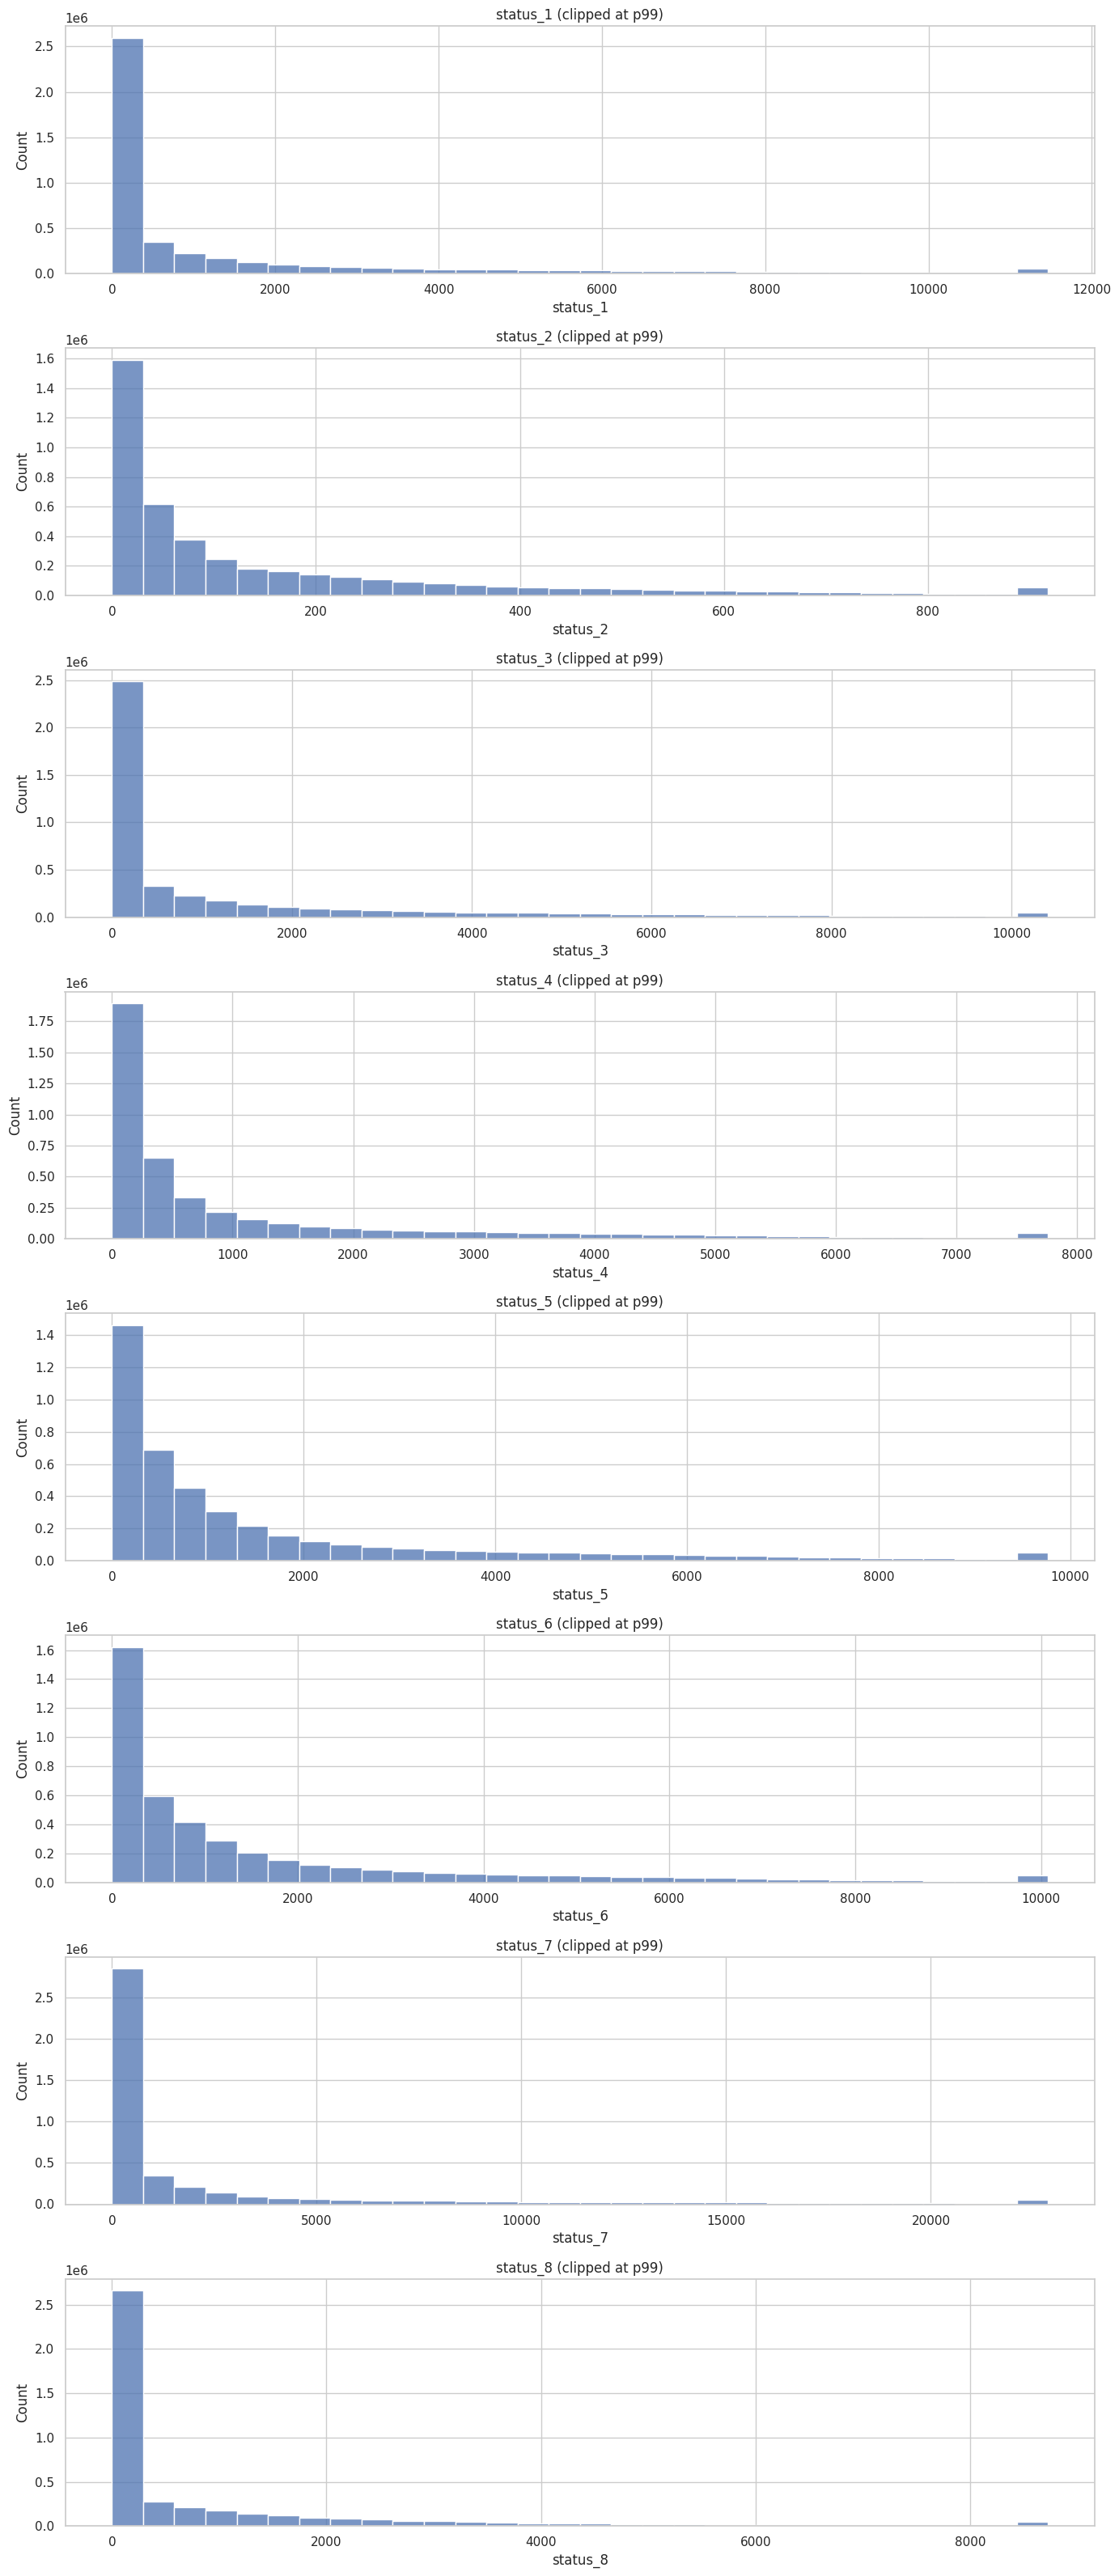

In [68]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


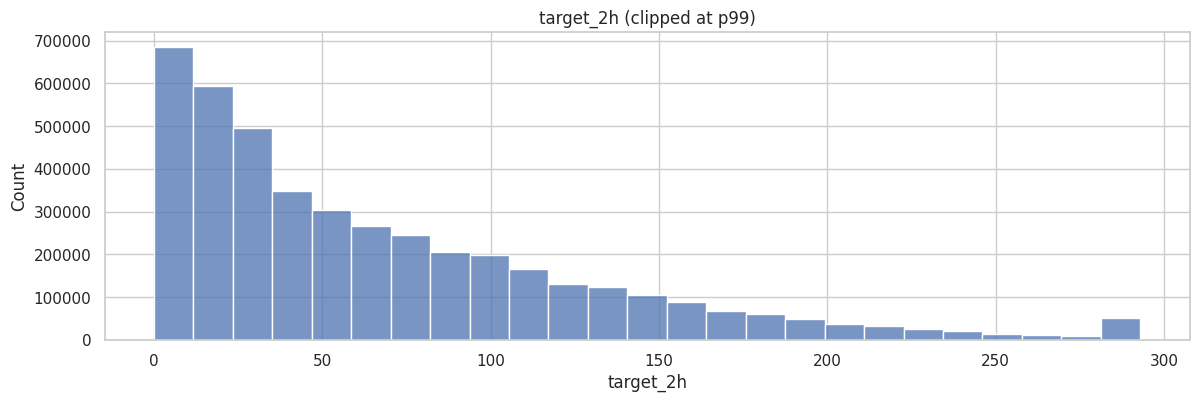

In [69]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(0.99)), bins=25, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()


## Генерируем будущие таргеты


In [70]:
route_group = train_df.groupby("route_id", sort=False)

for step in range(1, FORECAST_POINTS + 1):
    train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)

train_df[["route_id", "timestamp", TARGET_COL] + FUTURE_TARGET_COLS].head(10)


,route_id,timestamp,target_2h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
0,0,2025-03-01 00:00:00,79.0,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0
1,0,2025-03-01 00:30:00,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0
2,0,2025-03-01 01:00:00,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0
3,0,2025-03-01 01:30:00,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0
4,0,2025-03-01 02:00:00,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0
5,0,2025-03-01 02:30:00,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0
6,0,2025-03-01 03:00:00,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0
7,0,2025-03-01 03:30:00,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0
8,0,2025-03-01 04:00:00,33.0,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0,92.0
9,0,2025-03-01 04:30:00,33.0,27.0,6.0,6.0,6.0,0.0,0.0,0.0,31.0,92.0,92.0


In [71]:
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()
print("Rows with future targets:", supervised_df.shape)


Rows with future targets: (4332000, 22)


## Корреляции


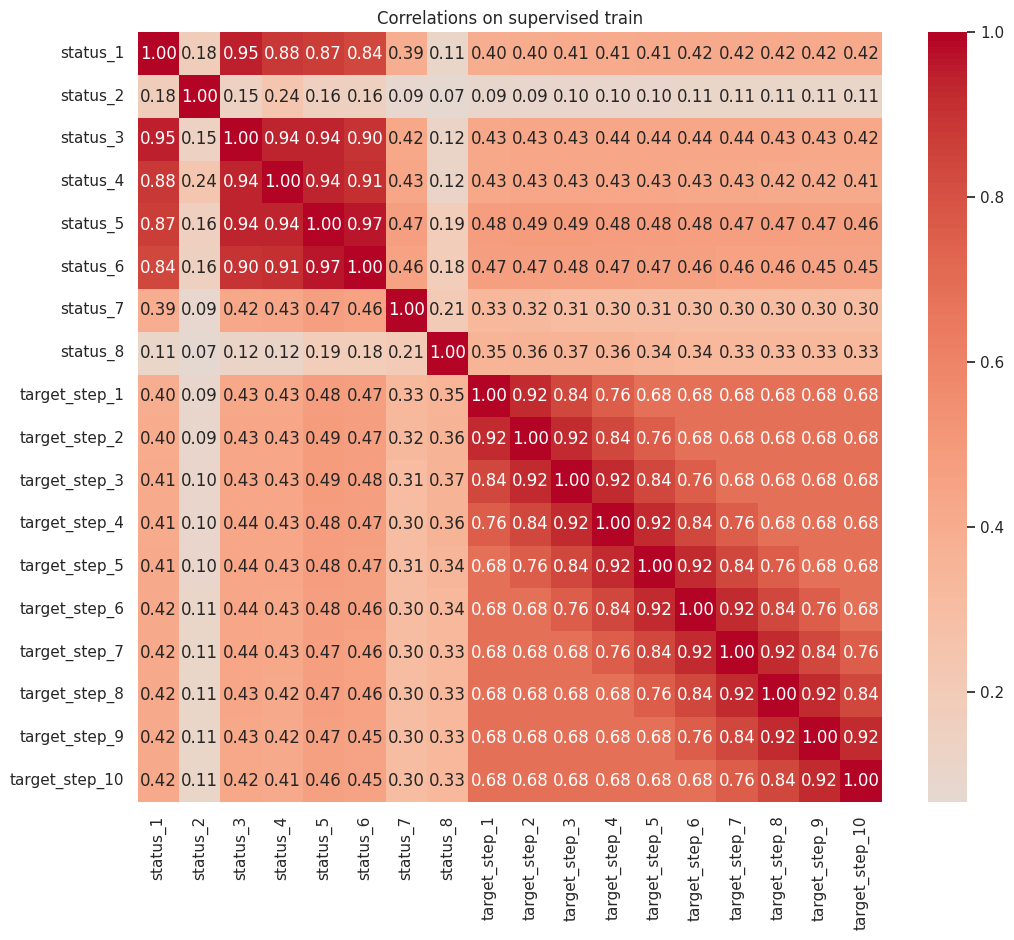

In [72]:
corr_cols = status_cols + FUTURE_TARGET_COLS
corr = supervised_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations on supervised train")
plt.show()


## Подготовка train и test


In [73]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)


Feature columns: ['office_from_id', 'route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']


In [74]:
train_model_df = supervised_df[feature_cols + ["timestamp"] + FUTURE_TARGET_COLS].copy()
train_model_df = train_model_df.rename(columns={"timestamp": "source_timestamp"})

train_ts_max = train_model_df["source_timestamp"].max()
train_window_start = train_ts_max - pd.Timedelta(days=TRAIN_DAYS)
train_model_df = train_model_df[train_model_df["source_timestamp"] >= train_window_start].copy()

print("Recent train rows:", train_model_df.shape)


Recent train rows: (673000, 21)


In [75]:
# последний момент факта, из которого делаем прогноз
inference_ts = train_df["timestamp"].max()
test_model_df = train_df[train_df["timestamp"] == inference_ts]

print("Test rows:", test_model_df.shape)


Test rows: (1000, 22)


## Time-based split


In [76]:
train_model_df = train_model_df.sort_values("source_timestamp").copy()
split_point = train_model_df["source_timestamp"].quantile(0.8)

fit_df = train_model_df[train_model_df["source_timestamp"] <= split_point].copy()
valid_df = train_model_df[train_model_df["source_timestamp"] > split_point].copy()

if len(fit_df) > MAX_TRAIN_ROWS:
    fit_df = fit_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE)

print("Fit rows:", fit_df.shape)
print("Valid rows:", valid_df.shape)


Fit rows: (539000, 21)
Valid rows: (134000, 21)


In [77]:
X_fit = fit_df[feature_cols].copy()
y_fit = fit_df[FUTURE_TARGET_COLS].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[FUTURE_TARGET_COLS].copy()

X_test = test_model_df[feature_cols].copy()


## Линейный baseline


In [78]:
categorical_features = [col for col in feature_cols if col.endswith("_id")]
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['office_from_id', 'route_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']


In [79]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=RIDGE_ALPHA)),
    ]
)


In [80]:
model.fit(X_fit, y_fit)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=fit_df.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=valid_df.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

valid_pred_df.head()


,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
3634110,22.473683,22.561544,22.629443,22.392158,22.089959,21.938313,21.875000,21.679252,21.594537,21.498519
807468,62.034483,62.068186,61.896039,60.781636,59.552215,58.929536,58.324910,57.740488,57.191445,56.837495
2066648,10.779956,10.556085,10.344572,10.108690,10.177625,10.279459,10.266133,10.382303,10.460485,10.488438
1276404,32.175533,31.724110,31.314853,30.745514,30.736801,30.971618,31.081087,31.056625,30.939416,30.759571
1840864,107.780271,108.629653,107.242338,105.827281,103.283665,102.791255,103.356878,104.295092,104.896487,105.541301


## Метрики


In [82]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias


metric = WapePlusRbias()

In [83]:
print('Метрики на тесте (по горизонтам):')
display(np.round(metric.calculate(y_fit, fit_pred_df), 2))

print('Общая метрика на тесте:')
print(f'{metric.calculate(y_fit.to_numpy().flatten(), fit_pred_df.to_numpy().flatten()):.2f}')

Метрики на тесте (по горизонтам):


target_step_1     0.29
target_step_2     0.29
target_step_3     0.29
target_step_4     0.29
target_step_5     0.29
target_step_6     0.30
target_step_7     0.30
target_step_8     0.30
target_step_9     0.30
target_step_10    0.30
dtype: float64

Общая метрика на тесте:
0.29


In [84]:
print('Метрики на валидации (по горизонтам):')
display(np.round(metric.calculate(y_valid, valid_pred_df), 2))

print('Общая метрика на валидации:')
print(f'{metric.calculate(y_valid.to_numpy().flatten(), valid_pred_df.to_numpy().flatten()):.2f}')

Метрики на валидации (по горизонтам):


target_step_1     0.31
target_step_2     0.31
target_step_3     0.31
target_step_4     0.31
target_step_5     0.32
target_step_6     0.32
target_step_7     0.33
target_step_8     0.33
target_step_9     0.34
target_step_10    0.34
dtype: float64

Общая метрика на валидации:
0.32


## Конвертируем прогноз в нужный формат 


In [85]:
# добавляем к прогнозу маршруты
test_pred_df['route_id'] = X_test['route_id']

# разворачиваем target_step_* в строки
forecast_df = test_pred_df.melt(
    id_vars="route_id",
    value_vars=[c for c in test_pred_df.columns if c.startswith("target_step_")],
    var_name="step",
    value_name="forecast"
)

# достаем номер шага из target_step_1, target_step_2, ...
forecast_df["step_num"] = forecast_df["step"].str.extract(r"(\d+)").astype(int)

# строим timestamp: каждый шаг = +30 минут от времени прогноза
forecast_df["timestamp"] = inference_ts + pd.to_timedelta(forecast_df["step_num"] * 30, unit="m")

# оставляем нужные столбцы
forecast_df = forecast_df[["route_id", "timestamp", "forecast"]].sort_values(
    ["route_id", "timestamp"]
).reset_index(drop=True)

forecast_df = test_df.merge(forecast_df, 'outer')[["id", "forecast"]]
forecast_df = forecast_df.rename(columns={"forecast": "y_pred"})

In [86]:
forecast_df.head()

,id,y_pred
0,4900,20.732610
1,4901,20.759690
2,4902,20.650796
3,4903,20.678948
4,4904,20.674415


In [87]:
# проверяем, что все точки получены
assert forecast_df['id'].isna().sum() == 0


## Выгрузка CSV


In [88]:
submission_path =  f"submission_{TRACK}.csv"
joined_path =  f"test_with_forecast_{TRACK}.csv"

forecast_df.to_csv(submission_path, index=False)

print("submission saved to:", submission_path)

submission saved to: submission_team.csv
